# 目标检测

1.环境检查（否则torch和torchvision不匹配会导致无法amp和nms）

In [2]:
import os
import torch
from ultralytics import YOLO
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

# 检查环境
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
# 首先检查VOC数据集的实际结构
def check_voc_structure():
    """检查VOC数据集的实际结构"""
    base_path = './VOCdevkit'
    
    print("=== VOC数据集结构检查 ===")
    
    # 检查VOC2007
    voc2007_jpeg = os.path.join(base_path, 'VOC2007/JPEGImages')
    if os.path.exists(voc2007_jpeg):
        jpeg_files = os.listdir(voc2007_jpeg)[:5]  # 显示前5个文件
        print(f"VOC2007 JPEGImages中的文件示例: {jpeg_files}")
    
    # 检查VOC2012
    voc2012_jpeg = os.path.join(base_path, 'VOC2012/JPEGImages')
    if os.path.exists(voc2012_jpeg):
        jpeg_files = os.listdir(voc2012_jpeg)[:5]
        print(f"VOC2012 JPEGImages中的文件示例: {jpeg_files}")
    
    # 检查train.txt内容
    train_txt_path = os.path.join(base_path, 'VOC2007/ImageSets/Main/train.txt')
    if os.path.exists(train_txt_path):
        with open(train_txt_path, 'r') as f:
            lines = f.readlines()[:10]  # 读取前10行
            print(f"train.txt内容示例: {[line.strip() for line in lines]}")
    
    return True

check_voc_structure()

WARNING ⚠️ torchvision==0.23 is incompatible with torch==2.9.
Run 'pip install torchvision==0.24' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation
PyTorch版本: 2.9.0
CUDA是否可用: True
=== VOC数据集结构检查 ===
VOC2007 JPEGImages中的文件示例: ['002662.jpg', '007960.jpg', '002933.jpg', '006134.jpg', '000132.jpg']
VOC2012 JPEGImages中的文件示例: ['2011_002932.jpg', '2012_004192.jpg', '2011_005836.jpg', '2012_001030.jpg', '2009_002652.jpg']
train.txt内容示例: ['008706', '007847', '001710', '009295', '000184', '007715', '005238', '009114', '006143', '004480']


True

2.数据转换（原生train.txt的内容为图片id,yolo只能使用路径）

In [5]:
# 手动创建YOLO格式的数据集
def convert_voc_to_yolo_format():
    """将VOC格式转换为YOLO格式"""
    import xml.etree.ElementTree as ET
    import shutil
    
    base_path = './VOCdevkit'
    output_path = './VOC_yolo_format'
    
    # 创建输出目录
    os.makedirs(os.path.join(output_path, 'images', 'train'), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'images', 'val'), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'labels', 'train'), exist_ok=True)
    os.makedirs(os.path.join(output_path, 'labels', 'val'), exist_ok=True)
    
    # VOC类别映射
    voc_classes = {
        'person': 0, 'bird': 1, 'cat': 2, 'cow': 3, 'dog': 4, 'horse': 5, 'sheep': 6,
        'airplane': 7, 'bicycle': 8, 'boat': 9, 'bus': 10, 'car': 11, 'motorcycle': 12, 'train': 13,
        'bottle': 14, 'chair': 15, 'diningtable': 16, 'pottedplant': 17, 'sofa': 18, 'tvmonitor': 19
    }
    
    def process_split(voc_year, split_name):
        """处理单个分割集"""
        # 读取分割文件
        split_file = os.path.join(base_path, f'VOC{voc_year}/ImageSets/Main/{split_name}.txt')
        if not os.path.exists(split_file):
            return []
        
        with open(split_file, 'r') as f:
            image_ids = [line.strip() for line in f.readlines()]
        
        processed_images = []
        
        for img_id in image_ids:
            # 源图像路径
            jpeg_path = os.path.join(base_path, f'VOC{voc_year}/JPEGImages/{img_id}.jpg')
            if not os.path.exists(jpeg_path):
                # 尝试其他扩展名
                jpeg_path = os.path.join(base_path, f'VOC{voc_year}/JPEGImages/{img_id}.JPEG')
                if not os.path.exists(jpeg_path):
                    continue
            
            # 目标图像路径
            dest_image = os.path.join(output_path, 'images', split_name, f'{voc_year}_{img_id}.jpg')
            shutil.copy2(jpeg_path, dest_image)
            
            # 处理标注文件
            xml_path = os.path.join(base_path, f'VOC{voc_year}/Annotations/{img_id}.xml')
            if os.path.exists(xml_path):
                # 解析XML并转换为YOLO格式
                tree = ET.parse(xml_path)
                root = tree.getroot()
                
                img_width = int(root.find('size/width').text)
                img_height = int(root.find('size/height').text)
                
                yolo_annotations = []
                
                for obj in root.findall('object'):
                    cls_name = obj.find('name').text
                    if cls_name not in voc_classes:
                        continue
                    
                    cls_id = voc_classes[cls_name]
                    bbox = obj.find('bndbox')
                    xmin = float(bbox.find('xmin').text)
                    ymin = float(bbox.find('ymin').text)
                    xmax = float(bbox.find('xmax').text)
                    ymax = float(bbox.find('ymax').text)
                    
                    # 转换为YOLO格式 (中心x, 中心y, 宽度, 高度)
                    x_center = (xmin + xmax) / 2 / img_width
                    y_center = (ymin + ymax) / 2 / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height
                    
                    yolo_annotations.append(f"{cls_id} {x_center} {y_center} {width} {height}")
                
                # 写入YOLO格式标注文件
                label_file = os.path.join(output_path, 'labels', split_name, f'{voc_year}_{img_id}.txt')
                with open(label_file, 'w') as f:
                    f.write('\n'.join(yolo_annotations))
            
            processed_images.append(dest_image)
        
        return processed_images
    
    # 处理训练集和验证集
    train_images = process_split('2007', 'train') + process_split('2012', 'train')
    val_images = process_split('2007', 'val')
    
    # 创建YOLO格式的数据集配置文件
    yolo_yaml = f"""
path: {os.path.abspath(output_path)}
train: images/train
val: images/val

nc: 20
names: {list(voc_classes.keys())}
"""
    
    with open(os.path.join(output_path, 'dataset.yaml'), 'w') as f:
        f.write(yolo_yaml)
    
    print(f"YOLO格式数据集已创建在: {output_path}")
    return os.path.join(output_path, 'dataset.yaml')

# 转换为YOLO格式（推荐方法）
yolo_config_path = convert_voc_to_yolo_format()

YOLO格式数据集已创建在: ./VOC_yolo_format


3.加载模型（v5稳定性最好）

In [3]:
# 加载YOLO模型（使用轻量级版本）
model = YOLO('yolov5nu.pt')  # 使用v5版本，因为v8跑不动
print("模型加载完成")

# 查看模型结构
print(f"模型类别数: {model.model.nc}")

模型加载完成
模型类别数: 80


4.训练yaml

In [4]:
# 训练模型
results = model.train(
    data=yolo_config_path,           # 数据集配置
    epochs=50,                 # 训练轮数
    imgsz=400,                 # 图像尺寸
    batch=8,                  # 批次大小
    lr0=0.01,                  # 初始学习率
    device='cuda' if torch.cuda.is_available() else 'cpu',  # 设备选择
    workers=4,                 # 数据加载工作进程数
    project='yolo_voc_detection',  # 项目名称
    name='exp1',               # 实验名称
    exist_ok=True,             # 允许覆盖现有实验
    verbose=True,              # 显示详细信息
    patience=10,               # 早停耐心值
    save=True,                 # 保存检查点
    # TensorBoard相关配置
    plots=True                # 生成训练曲线图
)

print("训练完成！")

Ultralytics 8.3.221 🚀 Python-3.13.7 torch-2.9.0 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./VOC_yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=400, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plot

5.可视化

In [ ]:
# 启动TensorBoard（坠机了）
# %load_ext tensorboard
# %tensorboard --logdir yolo_voc_detection/exp1

6.验证效果

In [6]:
# 验证模型性能
# 加载最佳模型
best_model = YOLO('yolo_voc_detection/exp1/weights/best.pt')

# 在验证集上评估
metrics = best_model.val(
    data=yolo_config_path,
    split='val',
    imgsz=640,
    batch=16,
    conf=0.25,  # 置信度阈值
    iou=0.6,    # IoU阈值
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("验证完成！")

# 显示验证结果 - 修正版本
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"平均精确率: {metrics.box.mp:.4f}")  # 使用 mp 而不是 precision
print(f"平均召回率: {metrics.box.mr:.4f}")  # 使用 mr 而不是 recall

Ultralytics 8.3.221 🚀 Python-3.13.7 torch-2.9.0 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
YOLOv5n summary (fused): 84 layers, 2,506,844 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3168.7±512.0 MB/s, size: 83.8 KB)
val: Scanning /home/magia/vscode/py/VOC_yolo_format/labels/val.cache... 1992 images, 120 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1992/1992 4.3Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 22.2it/s 5.6s0.1s
                   all       1992       5779      0.731      0.622      0.706      0.474
                person        817       2075      0.872      0.666      0.803      0.553
                  bird        143        241      0.778      0.611      0.728      0.487
                   cat        126        139      0.643      0.777      0.775      0.474
                   cow         52        126      0.787      0.738        0.8      0.5

7.测试效果


image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000001.jpg: 416x320 1 person, 3.3ms
Speed: 11.3ms preprocess, 3.3ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 320)
Results saved to /home/magia/vscode/py/runs/detect/predict


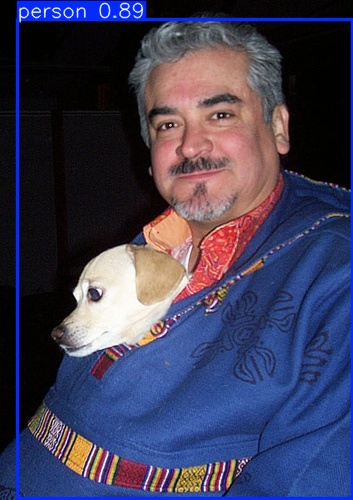

In [13]:
# 在测试集上进行预测
test_results = best_model(
    source='./VOCdevkit/VOC2007/JPEGImages/000001.jpg',  # 示例图像
    conf=0.25,
    save=True,
    show_labels=True,
    show_conf=True
)

# 显示预测结果
Image(filename='runs/detect/predict/000001.jpg')

8.批量测试

In [7]:
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Noto Serif CJK JP'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

# 批量测试和可视化
def visualize_predictions(model, image_paths, max_images=6):
    """可视化多个预测结果"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, img_path in enumerate(image_paths[:max_images]):
        # 进行预测
        results = model(img_path, conf=0.3)
        
        # 绘制结果
        result_img = results[0].plot()
        axes[i].imshow(result_img)
        axes[i].axis('off')
        axes[i].set_title(f'预测结果 {i+1}')
    
    plt.tight_layout()
    plt.show()

# 选择一些测试图像进行可视化
test_images = [
    './VOCdevkit/VOC2007/JPEGImages/000001.jpg',
    './VOCdevkit/VOC2007/JPEGImages/000002.jpg',
    './VOCdevkit/VOC2007/JPEGImages/000003.jpg',
    './VOCdevkit/VOC2007/JPEGImages/000004.jpg',
    './VOCdevkit/VOC2007/JPEGImages/000005.jpg',
    './VOCdevkit/VOC2007/JPEGImages/000006.jpg'
]

visualize_predictions(best_model, test_images)


image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000001.jpg: 416x320 1 person, 18.2ms
Speed: 0.6ms preprocess, 18.2ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 320)

image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000002.jpg: 416x288 1 train, 19.0ms
Speed: 0.6ms preprocess, 19.0ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 288)

image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000003.jpg: 320x416 (no detections), 17.5ms
Speed: 0.5ms preprocess, 17.5ms inference, 0.2ms postprocess per image at shape (1, 3, 320, 416)

image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000004.jpg: 352x416 9 cars, 19.4ms
Speed: 0.5ms preprocess, 19.4ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 416)

image 1/1 /home/magia/vscode/py/VOCdevkit/VOC2007/JPEGImages/000005.jpg: 320x416 4 chairs, 2.2ms
Speed: 0.4ms preprocess, 2.2ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 416)

image 1/1 /home/m

<Figure size 1500x1000 with 6 Axes>

9.保存输出

In [16]:
# 保存训练总结
def save_detailed_training_summary(model_path, metrics, model, output_file='detailed_training_summary.txt'):
    """保存详细的训练总结"""
    import os
    from datetime import datetime
    
    with open(output_file, 'w') as f:
        f.write("=== YOLO VOC目标检测详细训练总结 ===\n\n")
        
        # 基本信息
        f.write("## 基本信息\n")
        f.write(f"模型路径: {model_path}\n")
        if os.path.exists(model_path):
            mod_time = os.path.getmtime(model_path)
            f.write(f"训练完成时间: {datetime.fromtimestamp(mod_time).strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"模型大小: {os.path.getsize(model_path)/1024/1024:.2f} MB\n")
        
        # 总体性能指标
        f.write("\n## 总体性能指标\n")
        f.write(f"mAP50: {metrics.box.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.box.map:.4f}\n")
        f.write(f"平均精确率: {metrics.box.mp:.4f}\n")
        f.write(f"平均召回率: {metrics.box.mr:.4f}\n")
        f.write(f"平均F1分数: {metrics.box.f1.mean():.4f}\n")
        
        # 各类别性能
        f.write("\n## 各类别性能\n")
        for i, name in enumerate(model.names):
            if i < len(metrics.box.p):
                f.write(f"{name}: 精确率={metrics.box.p[i]:.4f}, 召回率={metrics.box.r[i]:.4f}, AP50={metrics.box.ap50[i]:.4f}\n")
        
        # 训练配置信息（如果可用）
        f.write("\n## 训练配置\n")
        try:
            # 尝试读取训练参数
            import yaml
            args_file = os.path.join(os.path.dirname(os.path.dirname(model_path)), 'args.yaml')
            if os.path.exists(args_file):
                with open(args_file, 'r') as args_f:
                    args_data = yaml.safe_load(args_f)
                    for key, value in args_data.items():
                        f.write(f"{key}: {value}\n")
        except:
            f.write("训练配置信息不可用\n")
    
    print(f"详细训练总结已保存到: {output_file}")

# 使用详细总结函数
save_detailed_training_summary('yolo_voc_detection/exp1/weights/best.pt', metrics, model)

详细训练总结已保存到: detailed_training_summary.txt
